# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [3]:
df = pd.read_csv(
    "data/cleaned_aviation_data.csv",
    low_memory=False,
)

df.shape

(17950, 34)

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [5]:
df["Aircraft.Size"] = np.where(
    df["Total.Passengers"] >= 20,
    "Large Passenger Aircraft",
    "Small Aircraft",
)

df["Aircraft.Size"].value_counts()

Aircraft.Size
Small Aircraft              17072
Large Passenger Aircraft      878
Name: count, dtype: int64

I separated aircraft into small aircraft and large passenger aircraft using a threshold of 20 estimated passengers. Aircraft with 20 or more estimated passengers were labeled as larger passenger aircraft, while aircraft below that threshold were labeled as smaller aircraft. This allows the analysis to provide separate recommendations for the two aircraft groups requested by the client.

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [14]:
make_injury_summary = (
    df.groupby(["Aircraft.Size", "Make"])
    .agg(
        accident_count=("Make", "size"),
        mean_fatal_serious_injury_fraction=(
            "Fatal.Serious.Injury.Fraction",
            "mean",
        ),
    )
    .reset_index()
)

min_records_per_group = 20

make_injury_summary_filtered = make_injury_summary[
    make_injury_summary["accident_count"] >= min_records_per_group
].copy()

lowest_15_makes_by_size = (
    make_injury_summary_filtered
    .sort_values(
        ["Aircraft.Size", "mean_fatal_serious_injury_fraction"],
        ascending=[True, True],
    )
    .groupby("Aircraft.Size")
    .head(15)
    .copy()
)

lowest_15_makes_by_size[
    "mean_fatal_serious_injury_percent"
] = (
    lowest_15_makes_by_size["mean_fatal_serious_injury_fraction"] * 100
)

lowest_15_makes_by_size

,Aircraft.Size,Make,accident_count,mean_fatal_serious_injury_fraction,mean_fatal_serious_injury_percent
8,Large Passenger Aircraft,MCDONNELL DOUGLAS,53,0.007827,0.782706
3,Large Passenger Aircraft,BOMBARDIER,65,0.039560,3.955964
2,Large Passenger Aircraft,BOEING,547,0.056771,5.677074
6,Large Passenger Aircraft,EMBRAER,78,0.065274,6.527402
0,Large Passenger Aircraft,AIRBUS,118,0.086249,8.624853
33,Small Aircraft,MCDONNELL DOUGLAS,55,0.094048,9.404762
21,Small Aircraft,BOMBARDIER,50,0.102308,10.230769
20,Small Aircraft,BOEING,714,0.141973,14.197270
32,Small Aircraft,MAULE,215,0.164806,16.480620
16,Small Aircraft,AVIAT,146,0.191781,19.178082


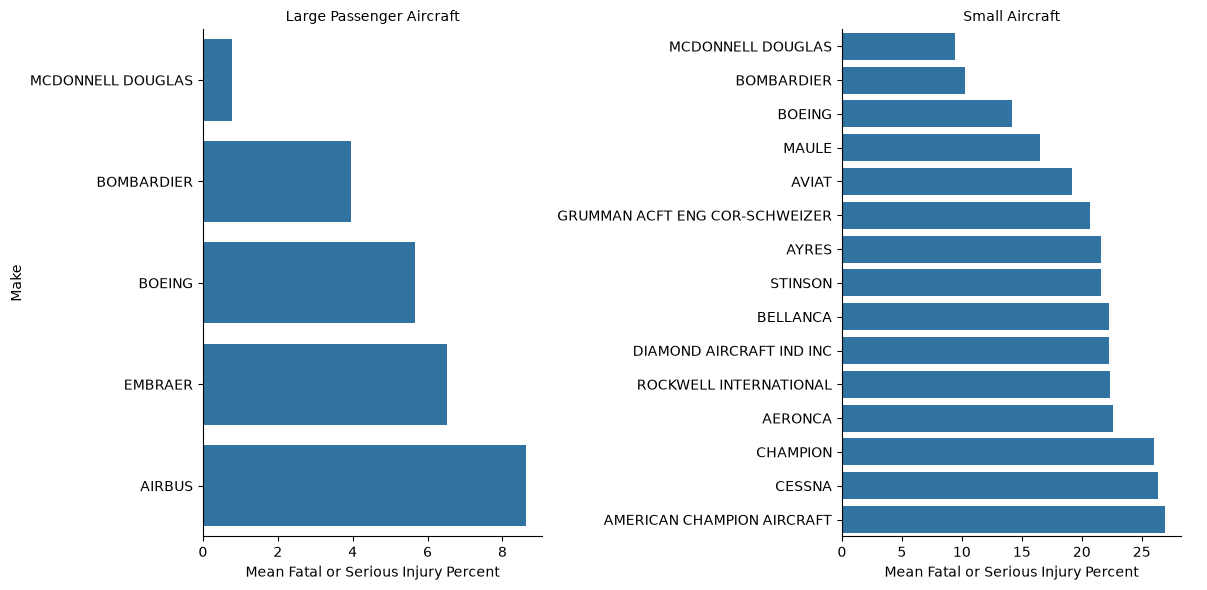

In [15]:
g = sns.catplot(
    data=lowest_15_makes_by_size,
    x="mean_fatal_serious_injury_percent",
    y="Make",
    col="Aircraft.Size",
    kind="bar",
    sharex=False,
    sharey=False,
    height=6,
    aspect=1,
)

g.set_axis_labels(
    "Mean Fatal or Serious Injury Percent",
    "Make",
)

g.set_titles("{col_name}")

plt.show()

I grouped the data by aircraft size and make, then calculated the mean fatal or serious injury fraction for each group. I used a minimum of 20 accident records per make and size group so the comparison would not rely on very small samples.

Although the prompt asks for 15 makes in each group, only 5 larger passenger aircraft makes met the 20 record threshold. I kept this threshold because including lower count makes would make the larger aircraft chart less reliable and could overstate risk based on too few accidents.

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

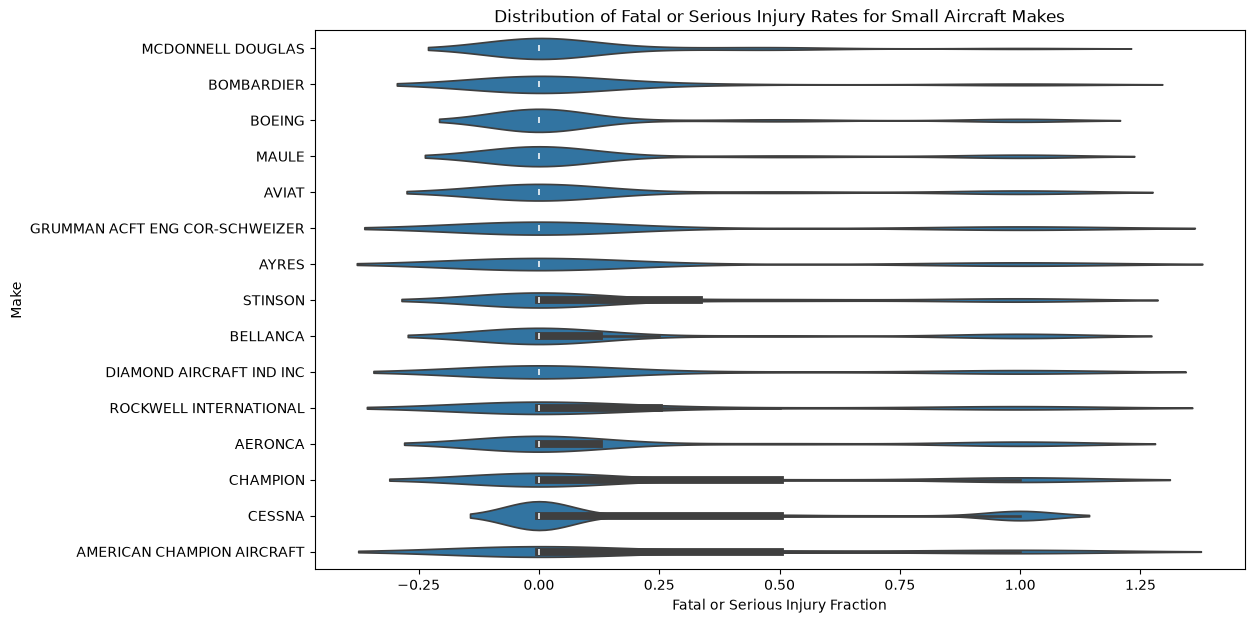

In [16]:
small_make_names = lowest_15_makes_by_size[
    lowest_15_makes_by_size["Aircraft.Size"] == "Small Aircraft"
]["Make"]

small_make_injury_data = df[
    (df["Aircraft.Size"] == "Small Aircraft")
    & (df["Make"].isin(small_make_names))
    & (df["Fatal.Serious.Injury.Fraction"].notna())
].copy()

plt.figure(figsize=(12, 7))

sns.violinplot(
    data=small_make_injury_data,
    x="Fatal.Serious.Injury.Fraction",
    y="Make",
    order=small_make_names,
)

plt.title("Distribution of Fatal or Serious Injury Rates for Small Aircraft Makes")
plt.xlabel("Fatal or Serious Injury Fraction")
plt.ylabel("Make")

plt.show()

This violin plot shows the distribution of fatal or serious injury fractions for the small aircraft makes with the lowest mean injury rates. The shape of each violin helps show whether a make has consistently low injury rates or whether the average is influenced by a wider range of accident outcomes.

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

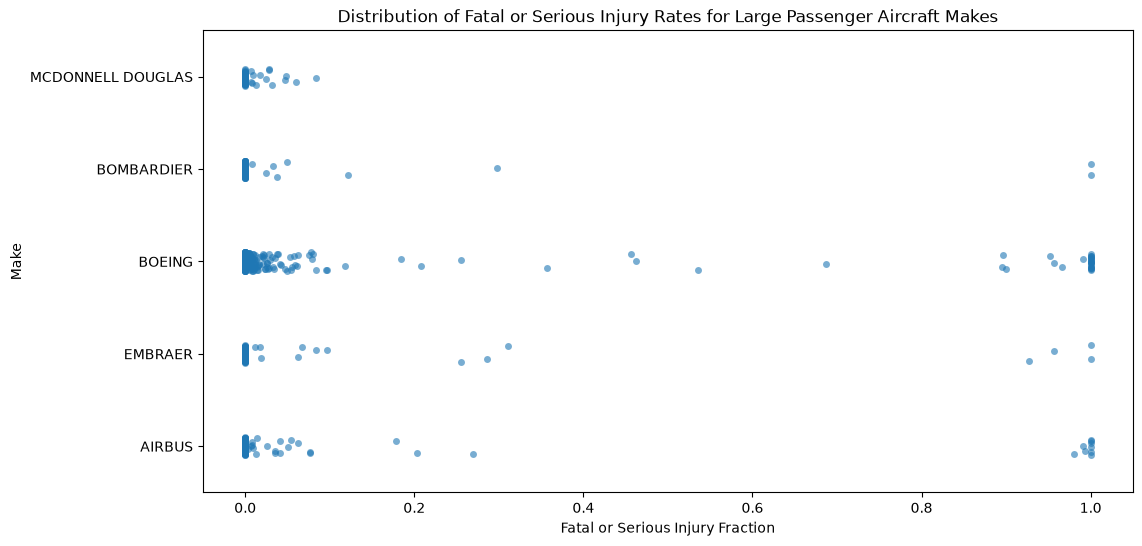

In [17]:
large_make_names = lowest_15_makes_by_size[
    lowest_15_makes_by_size["Aircraft.Size"] == "Large Passenger Aircraft"
]["Make"]

large_make_injury_data = df[
    (df["Aircraft.Size"] == "Large Passenger Aircraft")
    & (df["Make"].isin(large_make_names))
    & (df["Fatal.Serious.Injury.Fraction"].notna())
].copy()

plt.figure(figsize=(12, 6))

sns.stripplot(
    data=large_make_injury_data,
    x="Fatal.Serious.Injury.Fraction",
    y="Make",
    order=large_make_names,
    jitter=True,
    alpha=0.6,
)

plt.title("Distribution of Fatal or Serious Injury Rates for Large Passenger Aircraft Makes")
plt.xlabel("Fatal or Serious Injury Fraction")
plt.ylabel("Make")

plt.show()

This strip plot shows the distribution of fatal or serious injury fractions for the larger passenger aircraft makes with the lowest mean injury rates. Each point represents an accident record, which makes it easier to see how many observations support each make and whether the injury outcomes are tightly grouped or spread out.

Only 5 makes meet the 20 record sample size threshold for large passenger aircraft, so fewer than 10 are shown here. This reflects how few manufacturers have enough large-aircraft accident records in the data to support a reliable estimate

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [19]:
make_destruction_summary = (
    df.groupby(["Aircraft.Size", "Make"])
    .agg(
        accident_count=("Make", "size"),
        destruction_rate=("Aircraft.Destroyed", "mean"),
    )
    .reset_index()
)

min_records_per_group = 20

make_destruction_summary_filtered = make_destruction_summary[
    make_destruction_summary["accident_count"] >= min_records_per_group
].copy()

lowest_15_destruction_by_size = (
    make_destruction_summary_filtered
    .sort_values(
        ["Aircraft.Size", "destruction_rate"],
        ascending=[True, True],
    )
    .groupby("Aircraft.Size")
    .head(15)
    .copy()
)

lowest_15_destruction_by_size["destruction_rate_percent"] = (
    lowest_15_destruction_by_size["destruction_rate"] * 100
)

lowest_15_destruction_by_size = lowest_15_destruction_by_size.reset_index(drop=True)

lowest_15_destruction_by_size

,Aircraft.Size,Make,accident_count,destruction_rate,destruction_rate_percent
0,Large Passenger Aircraft,BOMBARDIER,65,0.030769,3.076923
1,Large Passenger Aircraft,BOEING,547,0.049360,4.936015
2,Large Passenger Aircraft,EMBRAER,78,0.051282,5.128205
3,Large Passenger Aircraft,MCDONNELL DOUGLAS,53,0.075472,7.547170
4,Large Passenger Aircraft,AIRBUS,118,0.076271,7.627119
5,Small Aircraft,LUSCOMBE,141,0.014184,1.418440
6,Small Aircraft,GRUMMAN ACFT ENG COR-SCHWEIZER,58,0.017241,1.724138
7,Small Aircraft,STINSON,129,0.023256,2.325581
8,Small Aircraft,AIRBUS,125,0.024000,2.400000
9,Small Aircraft,TAYLORCRAFT,93,0.032258,3.225806


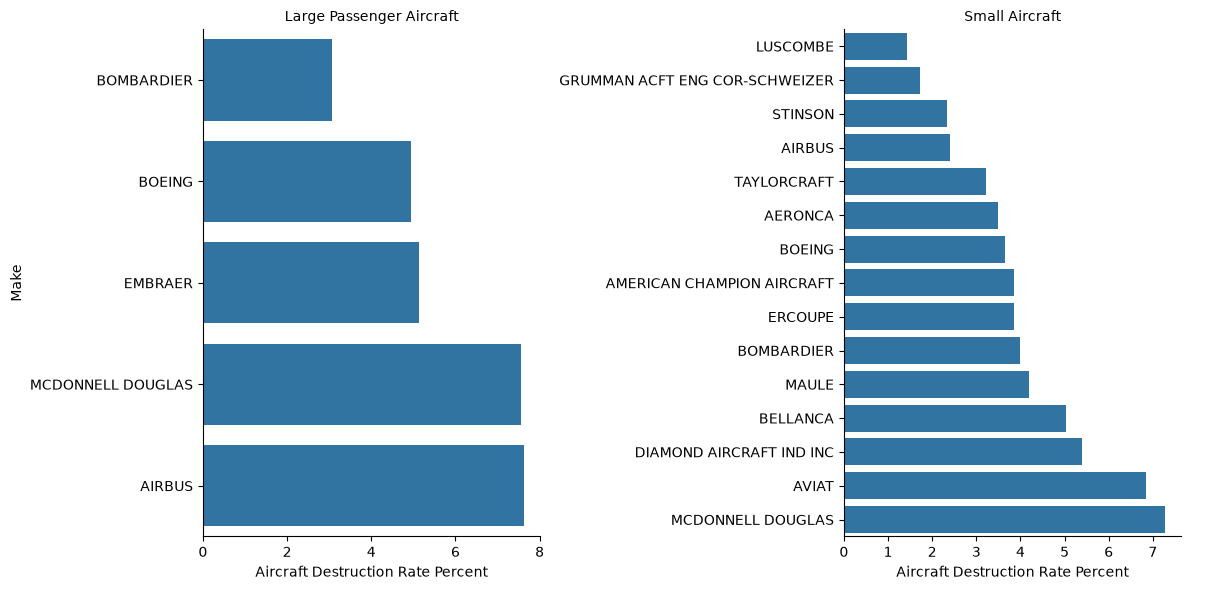

In [20]:
g = sns.catplot(
    data=lowest_15_destruction_by_size,
    x="destruction_rate_percent",
    y="Make",
    col="Aircraft.Size",
    kind="bar",
    sharex=False,
    sharey=False,
    height=6,
    aspect=1,
)

g.set_axis_labels(
    "Aircraft Destruction Rate Percent",
    "Make",
)

g.set_titles("{col_name}")

plt.show()

I grouped the data by aircraft size and make, then calculated the aircraft destruction rate for each group. I used a minimum of 20 accident records per make and size group so the comparison would not rely on very small samples.

The chart shows the qualifying makes in each aircraft size group with the lowest aircraft destruction rates. This metric is important because the client specifically asked for aircraft options with lower rates of total destruction.

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

The strongest recommendations are the makes that perform well on both injury and destruction metrics while also having enough accident records to support a reliable comparison.

For larger passenger aircraft, Bombardier and Boeing appear to be the strongest candidates at the make level. Bombardier has the lowest destruction rate among the larger aircraft group, while Boeing also has a low destruction rate and a much larger sample size. McDonnell Douglas has the lowest mean fatal or serious injury fraction in the larger aircraft group, but it also has a higher destruction rate, so I would not treat it as the primary recommendation without considering that tradeoff.

For smaller aircraft, Luscombe and Grumman Acft Eng Cor-Schweizer have the lowest destruction rates, but Luscombe does not appear among the makes with the lowest injury fractions. This suggests that Luscombe may be strong from an aircraft preservation perspective, but less clearly strong from a passenger injury perspective. Stinson and Aeronca appear to be more balanced options because they perform reasonably well across both the destruction rate and injury rate comparisons.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

In [25]:
df["Model"] = (
    df["Model"]
    .astype("string")
    .str.upper()
    .str.replace(r"[^A-Z0-9]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df["Plane.Type"] = df["Make"] + " " + df["Model"]

df[["Make", "Model", "Plane.Type"]].head()

,Make,Model,Plane.Type
0,BOEING,747,BOEING 747
1,PIPER,PA 28 140,PIPER PA 28 140
2,DE HAVILLAND,DHC 6,DE HAVILLAND DHC 6
3,BOEING,727 200,BOEING 727 200
4,BEECH,C35,BEECH C35


**Larger planes**

In [26]:
large_plane_type_summary = (
    df[df["Aircraft.Size"] == "Large Passenger Aircraft"]
    .groupby("Plane.Type")
    .agg(
        accident_count=("Plane.Type", "size"),
        mean_fatal_serious_injury_fraction=(
            "Fatal.Serious.Injury.Fraction",
            "mean",
        ),
    )
    .reset_index()
)

large_plane_type_summary = large_plane_type_summary[
    large_plane_type_summary["accident_count"] >= 10
].copy()

lowest_large_plane_types = (
    large_plane_type_summary
    .sort_values("mean_fatal_serious_injury_fraction")
    .head(15)
    .copy()
)

lowest_large_plane_types["mean_fatal_serious_injury_percent"] = (
    lowest_large_plane_types["mean_fatal_serious_injury_fraction"] * 100
)

lowest_large_plane_types = lowest_large_plane_types.reset_index(drop=True)

lowest_large_plane_types

,Plane.Type,accident_count,mean_fatal_serious_injury_fraction,mean_fatal_serious_injury_percent
0,BOEING 777,33,0.000821,0.082099
1,BOEING 757,18,0.001473,0.147287
2,BOEING 787,11,0.003058,0.305832
3,BOMBARDIER CL 600 2B19,19,0.003265,0.326511
4,EMBRAER EMB 145LR,18,0.008333,0.833333
5,EMBRAER EMB145,11,0.008798,0.879765
6,BOMBARDIER CL 600 2C10,14,0.009233,0.923251
7,BOEING 747,11,0.023161,2.316150
8,BOEING 737 7H4,26,0.038177,3.817688
9,BOEING 767,31,0.046963,4.696260


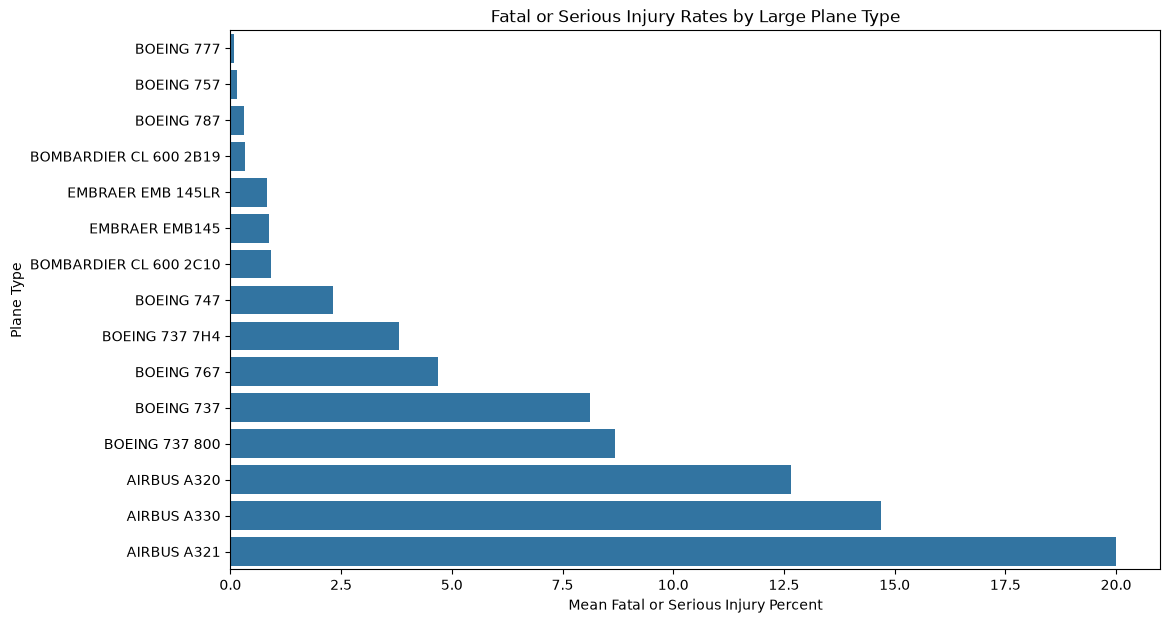

In [29]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=lowest_large_plane_types,
    x="mean_fatal_serious_injury_percent",
    y="Plane.Type",
)

plt.title("Fatal or Serious Injury Rates by Large Plane Type")
plt.xlabel("Mean Fatal or Serious Injury Percent")
plt.ylabel("Plane Type")

plt.show()

This bar chart shows the large plane types with the lowest mean fatal or serious injury percentages among plane types with at least 10 accident records.

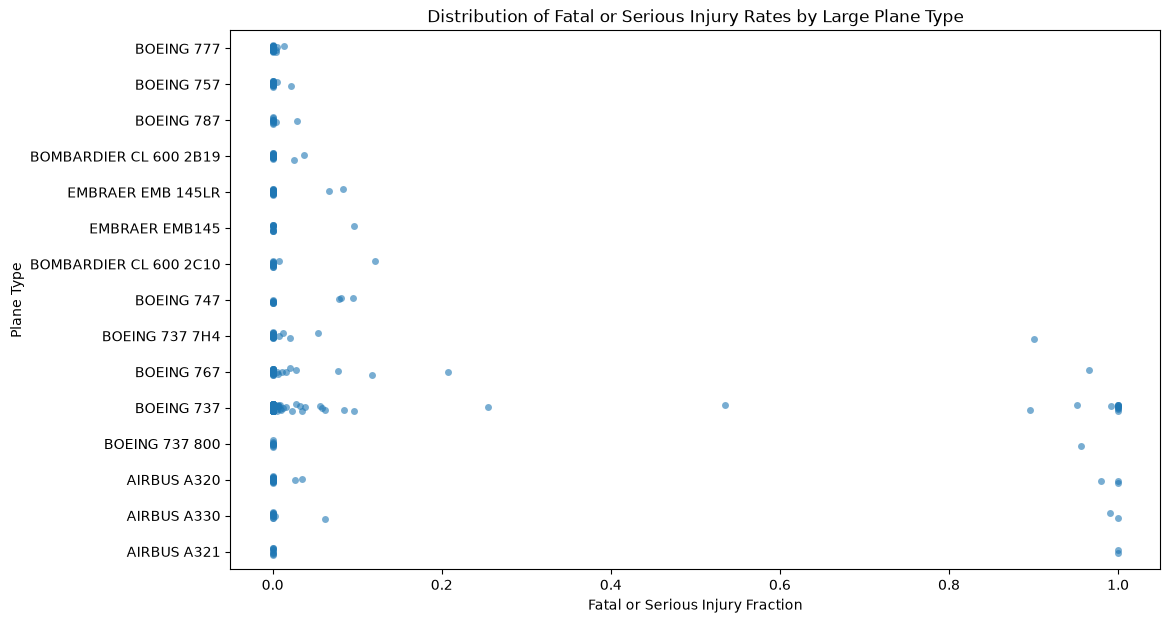

In [30]:
large_plane_type_names = lowest_large_plane_types["Plane.Type"]

large_plane_type_data = df[
    (df["Aircraft.Size"] == "Large Passenger Aircraft")
    & (df["Plane.Type"].isin(large_plane_type_names))
    & (df["Fatal.Serious.Injury.Fraction"].notna())
].copy()

plt.figure(figsize=(12, 7))

sns.stripplot(
    data=large_plane_type_data,
    x="Fatal.Serious.Injury.Fraction",
    y="Plane.Type",
    order=large_plane_type_names,
    jitter=True,
    alpha=0.6,
)

plt.title("Distribution of Fatal or Serious Injury Rates by Large Plane Type")
plt.xlabel("Fatal or Serious Injury Fraction")
plt.ylabel("Plane Type")

plt.show()

This strip plot shows the individual accident records behind the large plane type averages, making it easier to see whether the lower injury rates are consistent or influenced by a few unusual records.

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [27]:
small_plane_type_summary = (
    df[df["Aircraft.Size"] == "Small Aircraft"]
    .groupby(["Make", "Plane.Type"])
    .agg(
        accident_count=("Plane.Type", "size"),
        mean_fatal_serious_injury_fraction=(
            "Fatal.Serious.Injury.Fraction",
            "mean",
        ),
    )
    .reset_index()
)

small_plane_type_summary = small_plane_type_summary[
    small_plane_type_summary["accident_count"] >= 10
].copy()

lowest_10_small_makes = lowest_15_makes_by_size[
    lowest_15_makes_by_size["Aircraft.Size"] == "Small Aircraft"
]["Make"].head(10)

lowest_small_plane_types = (
    small_plane_type_summary[
        small_plane_type_summary["Make"].isin(lowest_10_small_makes)
    ]
    .sort_values("mean_fatal_serious_injury_fraction")
    .head(15)
    .copy()
)

lowest_small_plane_types["mean_fatal_serious_injury_percent"] = (
    lowest_small_plane_types["mean_fatal_serious_injury_fraction"] * 100
)

lowest_small_plane_types = lowest_small_plane_types.reset_index(drop=True)

lowest_small_plane_types

,Make,Plane.Type,accident_count,mean_fatal_serious_injury_fraction,mean_fatal_serious_injury_percent
0,BOEING,BOEING 737 800,14,0.000000,0.000000
1,MAULE,MAULE M 5 210C,11,0.000000,0.000000
2,BOEING,BOEING 777,43,0.000000,0.000000
3,BOEING,BOEING 787,14,0.000000,0.000000
4,STINSON,STINSON 108 1,18,0.074074,7.407407
5,BOEING,BOEING 747,57,0.076923,7.692308
6,BOEING,BOEING 737,240,0.083333,8.333333
7,AVIAT,AVIAT A 1,12,0.083333,8.333333
8,BELLANCA,BELLANCA 7ECA,25,0.120000,12.000000
9,MAULE,MAULE MX7,18,0.125000,12.500000


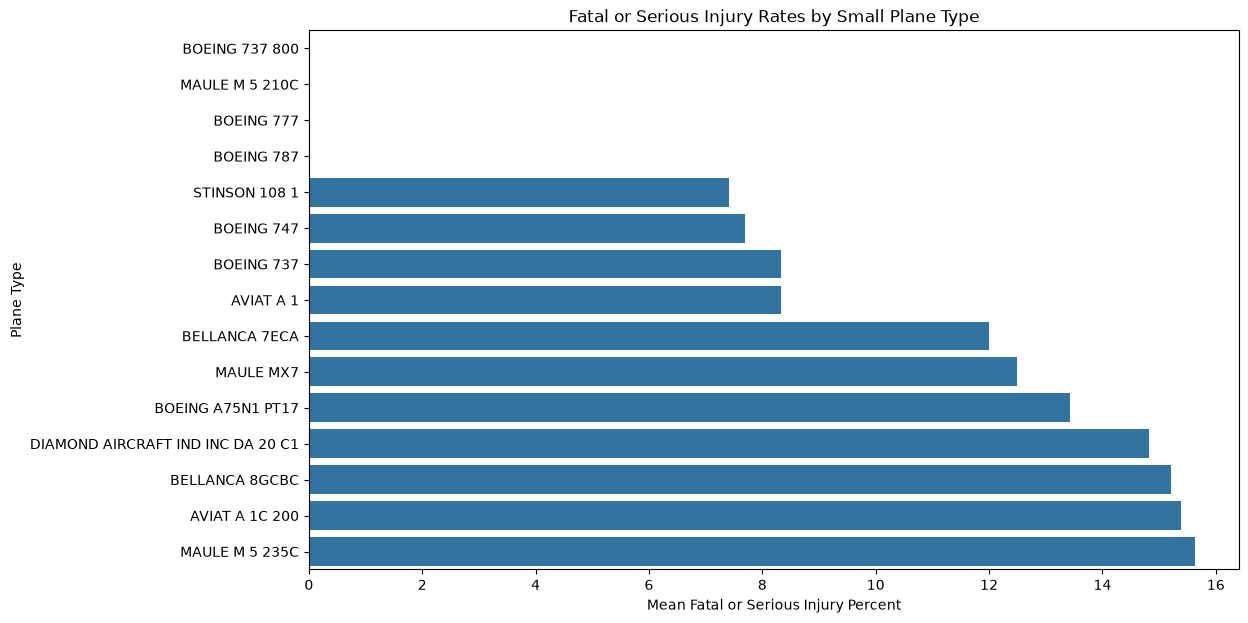

In [33]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=lowest_small_plane_types,
    x="mean_fatal_serious_injury_percent",
    y="Plane.Type",
)

plt.title("Fatal or Serious Injury Rates by Small Plane Type")
plt.xlabel("Mean Fatal or Serious Injury Percent")
plt.ylabel("Plane Type")

plt.show()

This bar chart shows the small plane types with the lowest mean fatal or serious injury percentages within the small aircraft makes that had the lowest overall injury rates.

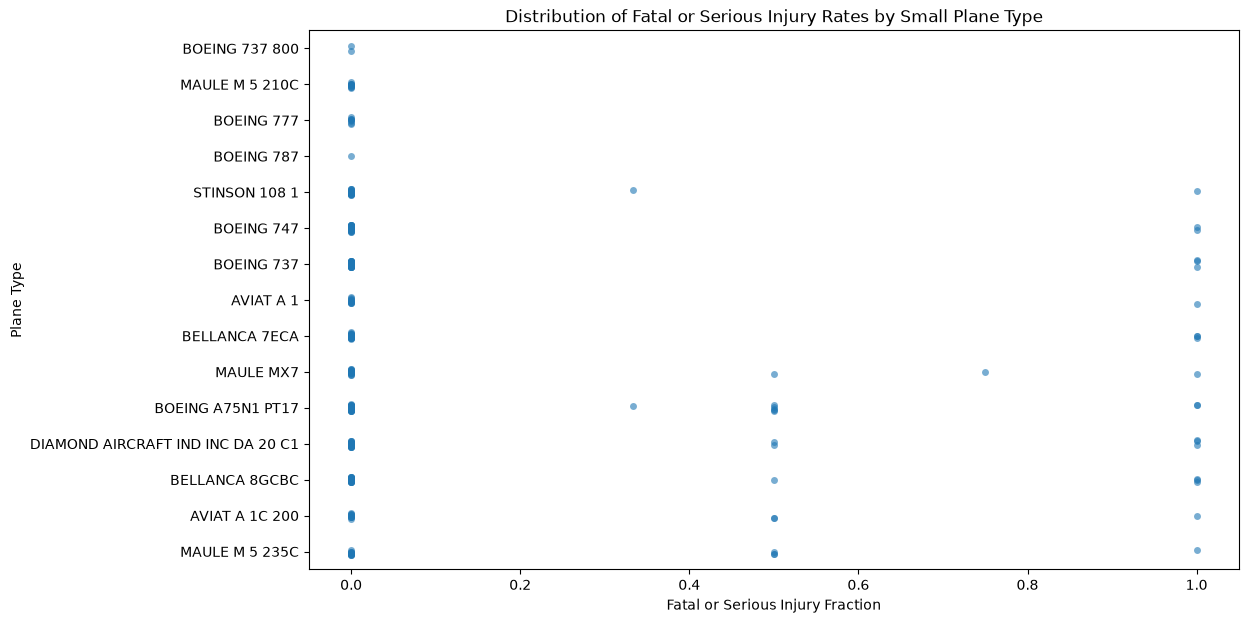

In [32]:
small_plane_type_names = lowest_small_plane_types["Plane.Type"]

small_plane_type_data = df[
    (df["Aircraft.Size"] == "Small Aircraft")
    & (df["Plane.Type"].isin(small_plane_type_names))
    & (df["Fatal.Serious.Injury.Fraction"].notna())
].copy()

plt.figure(figsize=(12, 7))

sns.stripplot(
    data=small_plane_type_data,
    x="Fatal.Serious.Injury.Fraction",
    y="Plane.Type",
    order=small_plane_type_names,
    jitter=True,
    alpha=0.6,
)

plt.title("Distribution of Fatal or Serious Injury Rates by Small Plane Type")
plt.xlabel("Fatal or Serious Injury Fraction")
plt.ylabel("Plane Type")

plt.show()

This strip plot shows the individual accident records behind the small plane type averages, which helps show how much variation exists within each recommended plane type.

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Breaking the analysis down from Make to individual Plane.Type shows variation that the Make averages were hiding. Among large passenger aircraft, Boeing's 777, 757, and 787 have the lowest mean fatal or serious injury percentages in the plane type table. Boeing's 747 also performs reasonably well, but it is not as strong as the 777, 757, and 787 group. The Bombardier CL 600 and Embraer EMB 145 variants also perform well, staying under 1% in the ranked results. By contrast, the Airbus A320, A330, and A321 appear lower in the ranking, with higher injury percentages than the other large aircraft types shown.

For small aircraft, the plane type breakdown reveals an important limitation in the size classification. Several Boeing commercial aircraft appear in the small aircraft results because those accident records involved fewer than 20 estimated passengers, not because the aircraft itself is a small general aviation plane. These records should be interpreted as low-occupancy accidents rather than true small aircraft examples. One exception is the Boeing A75N1 PT17, which is a vintage trainer aircraft rather than a modern commercial jet, so it fits more naturally with the small aircraft discussion.

Among the more clearly small aircraft types, the Maule M 5 210C stands out with a 0% mean fatal or serious injury rate in the plotted results. Stinson 108 1, Aviat A 1, Bellanca 7ECA, Maule MX7, Diamond DA 20 C1, Bellanca 8GCBC, Aviat A 1C 200, Maule M 5 235C, and Boeing A75N1 PT17 also appear in the lower injury group, but their rates are more spread out than the strongest large aircraft results.

This plane type analysis refines the earlier Make-level recommendations. At the Make level, Boeing and Bombardier were among the strongest large aircraft candidates, but the plane type results show that Boeing's stronger performance is mainly driven by specific aircraft types such as the 777, 757, and 787 rather than the entire Boeing product line. The Boeing 737 and 737 800 have higher injury percentages than Boeing's strongest large aircraft types, so I would not recommend all Boeing aircraft equally. For large passenger aircraft, I would prioritize Boeing's 777, 757, and 787, along with the Bombardier CL 600 and Embraer EMB 145 variants. For smaller aircraft, I would prioritize Maule M 5 210C, then consider Stinson 108 1, Aviat A 1, Bellanca 7ECA, and Boeing A75N1 PT17 as secondary candidates, while keeping the 10-record minimum in mind when interpreting these averages.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

## Engine Count

In [39]:
engine_count_summary = (
    df.groupby("Number.of.Engines")
    .agg(
        accident_count=("Number.of.Engines", "size"),
        mean_fatal_serious_injury_fraction=(
            "Fatal.Serious.Injury.Fraction",
            "mean",
        ),
        destruction_rate=("Aircraft.Destroyed", "mean"),
    )
    .reset_index()
)

engine_count_summary = engine_count_summary[
    (engine_count_summary["Number.of.Engines"] > 0)
    & (engine_count_summary["accident_count"] >= 20)
].copy()

engine_count_summary["mean_fatal_serious_injury_percent"] = (
    engine_count_summary["mean_fatal_serious_injury_fraction"] * 100
)

engine_count_summary["destruction_rate_percent"] = (
    engine_count_summary["destruction_rate"] * 100
)

engine_count_summary = engine_count_summary.sort_values("Number.of.Engines")

engine_count_summary

,Number.of.Engines,accident_count,mean_fatal_serious_injury_fraction,destruction_rate,mean_fatal_serious_injury_percent,destruction_rate_percent
1,1.0,13291,0.255898,0.077647,25.589830,7.764653
2,2.0,2470,0.276332,0.135628,27.633249,13.562753
3,3.0,26,0.082690,0.038462,8.269017,3.846154
4,4.0,67,0.139095,0.089552,13.909502,8.955224


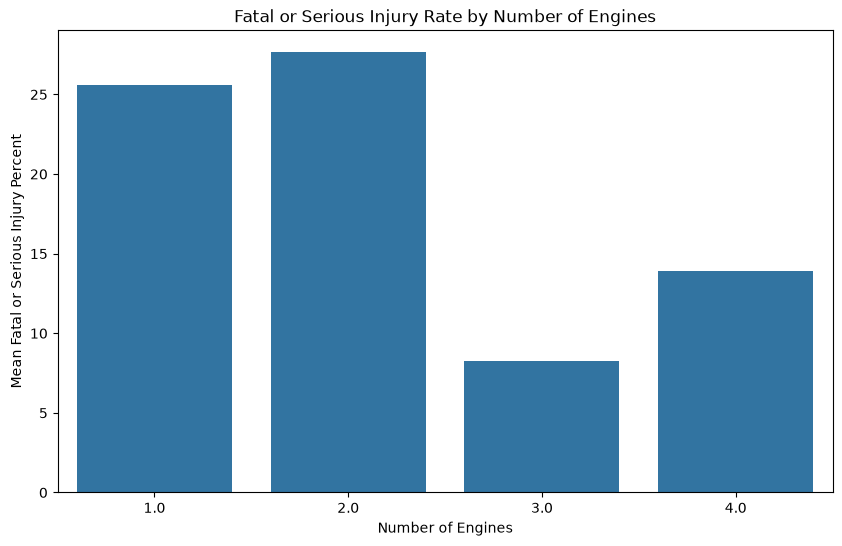

In [40]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=engine_count_summary,
    x="Number.of.Engines",
    y="mean_fatal_serious_injury_percent",
)

plt.title("Fatal or Serious Injury Rate by Number of Engines")
plt.xlabel("Number of Engines")
plt.ylabel("Mean Fatal or Serious Injury Percent")

plt.show()

This chart compares mean fatal or serious injury percentages across engine count groups with at least 20 accident records.

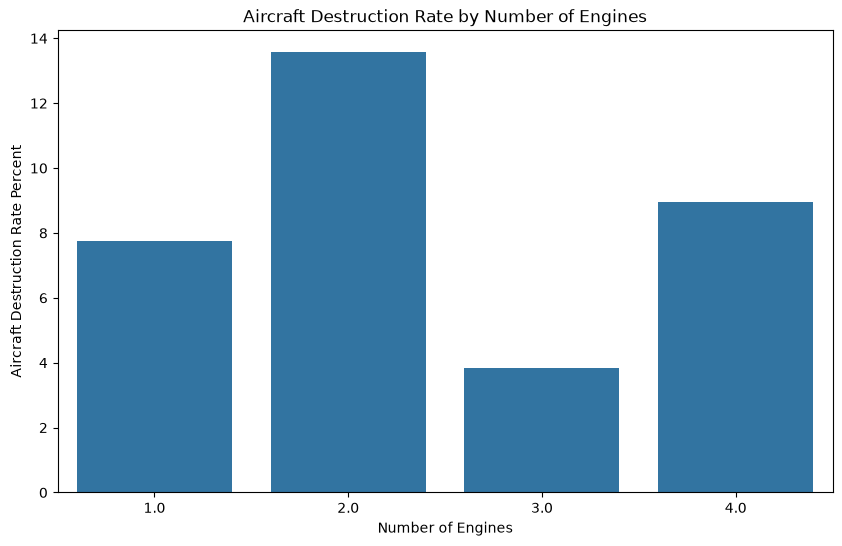

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=engine_count_summary,
    x="Number.of.Engines",
    y="destruction_rate_percent",
)

plt.title("Aircraft Destruction Rate by Number of Engines")
plt.xlabel("Number of Engines")
plt.ylabel("Aircraft Destruction Rate Percent")

plt.show()

This chart compares aircraft destruction rates across engine count groups, giving a separate view of aircraft damage severity.

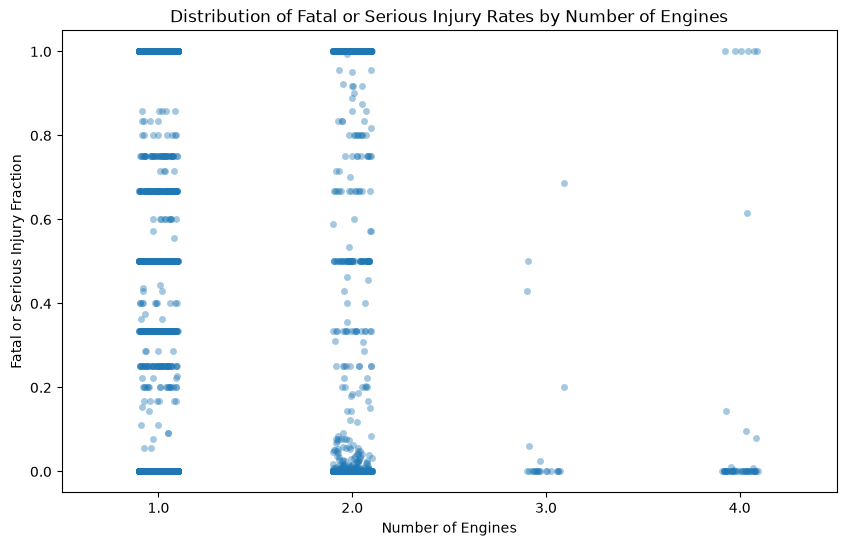

In [42]:
engine_count_values = engine_count_summary["Number.of.Engines"]

engine_count_distribution_data = df[
    (df["Number.of.Engines"].isin(engine_count_values))
    & (df["Fatal.Serious.Injury.Fraction"].notna())
].copy()

plt.figure(figsize=(10, 6))

sns.stripplot(
    data=engine_count_distribution_data,
    x="Number.of.Engines",
    y="Fatal.Serious.Injury.Fraction",
    jitter=True,
    alpha=0.4,
)

plt.title("Distribution of Fatal or Serious Injury Rates by Number of Engines")
plt.xlabel("Number of Engines")
plt.ylabel("Fatal or Serious Injury Fraction")

plt.show()

This strip plot shows the individual injury fraction records behind the engine count averages, which helps show whether the mean is representative or influenced by outliers.

## Analysis

Number of Engines was analyzed as an aircraft configuration factor that may relate to both passenger injury severity and aircraft damage severity. I filtered out engine count groups with fewer than 20 accident records and removed the 0-engine group because it had too few records to support meaningful analysis.

The results show that engine count does not have a simple relationship with accident severity. Two-engine aircraft had the highest mean fatal or serious injury percentage at 27.6% and the highest aircraft destruction rate at 13.6%. This is higher than single-engine aircraft, which had a 25.6% mean fatal or serious injury percentage and a 7.8% destruction rate. This is somewhat counterintuitive because two-engine aircraft have engine redundancy, but the results suggest that engine count alone does not explain safety outcomes.

Three-engine and four-engine aircraft showed lower severity in this dataset, with three-engine aircraft at 8.3% mean fatal or serious injury and 3.8% destruction, and four-engine aircraft at 13.9% mean fatal or serious injury and 9.0% destruction. However, these groups had much smaller sample sizes than the one-engine and two-engine groups.

## Weather Condition

VMC represents visual meteorological conditions, where visibility is generally good enough for pilots to rely on outside visual references. IMC represents instrument meteorological conditions, where visibility is reduced and pilots must rely more heavily on flight instruments.

In [43]:
weather_summary = (
    df.groupby("Weather.Condition")
    .agg(
        accident_count=("Weather.Condition", "size"),
        mean_fatal_serious_injury_fraction=(
            "Fatal.Serious.Injury.Fraction",
            "mean",
        ),
        destruction_rate=("Aircraft.Destroyed", "mean"),
    )
    .reset_index()
)

weather_summary = weather_summary[
    weather_summary["accident_count"] >= 20
].copy()

weather_summary["mean_fatal_serious_injury_percent"] = (
    weather_summary["mean_fatal_serious_injury_fraction"] * 100
)

weather_summary["destruction_rate_percent"] = (
    weather_summary["destruction_rate"] * 100
)

weather_summary = weather_summary.sort_values(
    "mean_fatal_serious_injury_percent"
)

weather_summary

,Weather.Condition,accident_count,mean_fatal_serious_injury_fraction,destruction_rate,mean_fatal_serious_injury_percent,destruction_rate_percent
2,VMC,14357,0.232942,0.071045,23.294170,7.104548
1,UNKNOWN,262,0.427316,0.263359,42.731604,26.335878
0,IMC,910,0.628964,0.348352,62.896400,34.835165


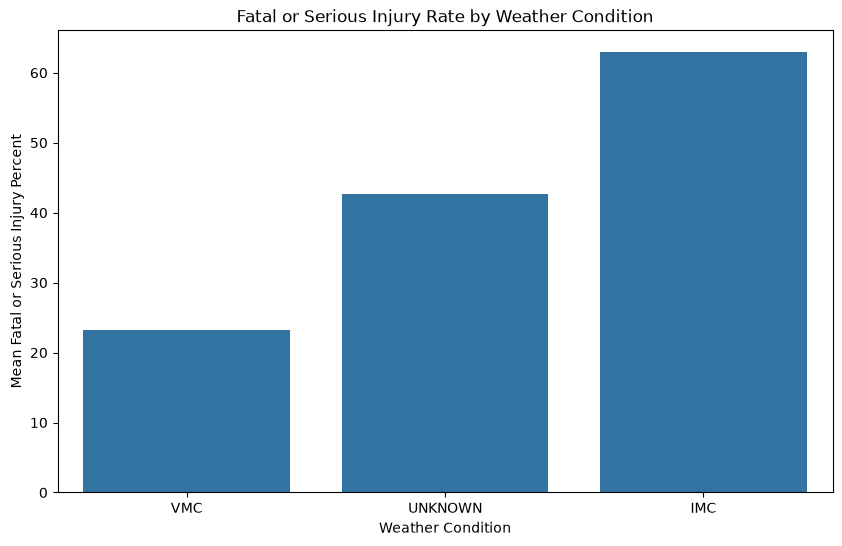

In [44]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=weather_summary,
    x="Weather.Condition",
    y="mean_fatal_serious_injury_percent",
)

plt.title("Fatal or Serious Injury Rate by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Mean Fatal or Serious Injury Percent")

plt.show()

This chart compares mean fatal or serious injury percentages across weather condition groups with at least 20 accident records.

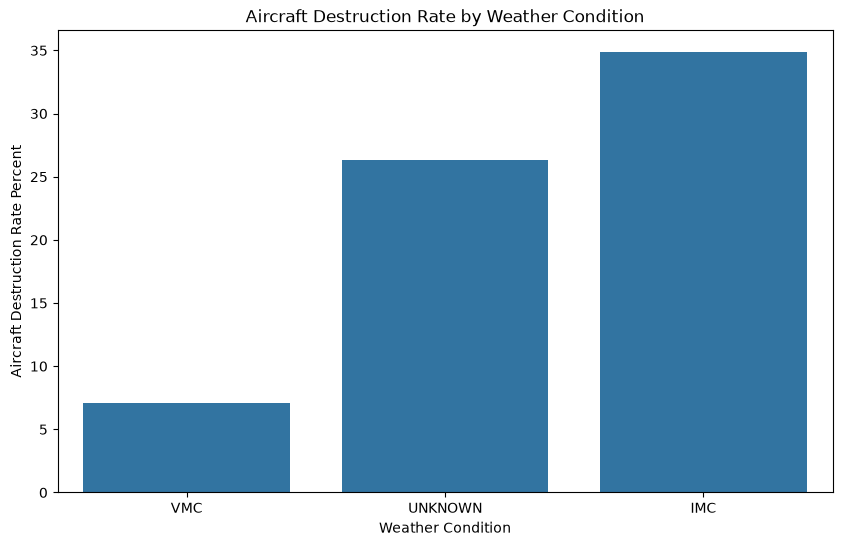

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=weather_summary,
    x="Weather.Condition",
    y="destruction_rate_percent",
)

plt.title("Aircraft Destruction Rate by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Aircraft Destruction Rate Percent")

plt.show()

This chart compares aircraft destruction rates by weather condition, giving a second view of accident severity beyond passenger injury outcomes.

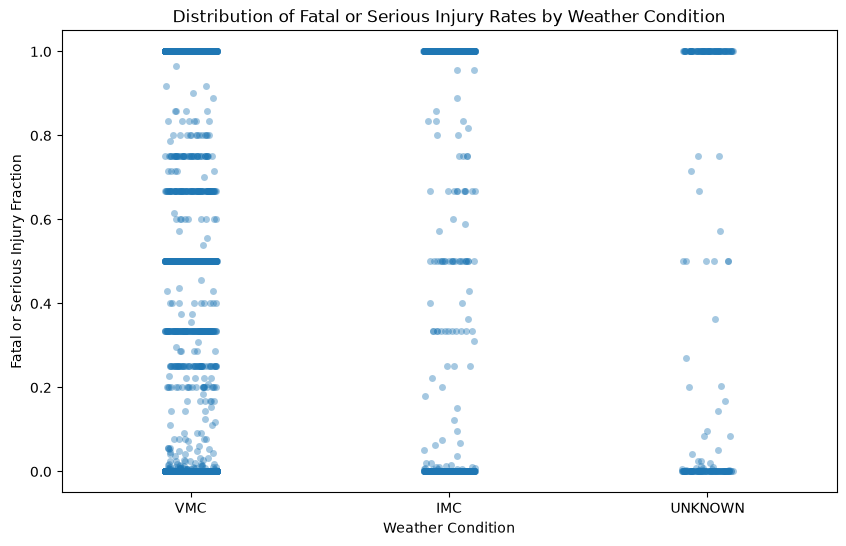

In [46]:
weather_condition_values = weather_summary["Weather.Condition"]

weather_distribution_data = df[
    (df["Weather.Condition"].isin(weather_condition_values))
    & (df["Fatal.Serious.Injury.Fraction"].notna())
].copy()

plt.figure(figsize=(10, 6))

sns.stripplot(
    data=weather_distribution_data,
    x="Weather.Condition",
    y="Fatal.Serious.Injury.Fraction",
    jitter=True,
    alpha=0.4,
)

plt.title("Distribution of Fatal or Serious Injury Rates by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Fatal or Serious Injury Fraction")

plt.show()

This strip plot shows the individual injury fraction records behind each weather condition average, helping identify whether the mean is representative or influenced by outliers.

## Analysis

Weather Condition was analyzed as an environmental factor that may affect both passenger injury severity and aircraft damage severity. The three weather groups in the dataset were VMC, IMC, and UNKNOWN, and all three had enough accident records to compare.

The results show a clear difference between VMC and IMC accidents. IMC had the highest severity, with a 62.9% mean fatal or serious injury percentage and a 34.8% destruction rate. VMC was much lower, with a 23.3% mean fatal or serious injury percentage and a 7.1% destruction rate. UNKNOWN fell between the two at 42.7% and 26.3%, but I would treat this category cautiously due to it likely including a mix of conditions that were not recorded clearly.

Overall, weather condition appears to be one of the strongest factors in this analysis. IMC conditions are more dangerous because pilots have less outside visibility and must rely more on instruments. Since both VMC and IMC have large sample sizes, this difference is more reliable than some of the smaller engine count groups.